In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import r2_score, root_mean_squared_error

In [3]:
#loading dataset
df=pd.read_csv("50_Startups.csv")
df.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [4]:
#checking null values
df.isnull().sum()

R&D Spend          0
Administration     0
Marketing Spend    0
State              0
Profit             0
dtype: int64

In [5]:
#checking O metrics
print((df == 0).sum())

R&D Spend          2
Administration     0
Marketing Spend    3
State              0
Profit             0
dtype: int64


In [6]:
#filled 0 metrics with median value
df[["R&D Spend", "Marketing Spend"]] = df[["R&D Spend", "Marketing Spend"]].replace(0, np.nan)
impute=SimpleImputer(missing_values=np.nan, strategy='median')
df[["R&D Spend", "Marketing Spend"]] = impute.fit_transform(df[["R&D Spend", "Marketing Spend"]] )
print((df == 0).sum())


R&D Spend          0
Administration     0
Marketing Spend    0
State              0
Profit             0
dtype: int64


In [7]:
#separating independent & dependent variables
X=df.iloc[:, :-1].values
y=df.iloc[:, -1].values
print(X)    
print(y)

[[165349.2 136897.8 471784.1 'New York']
 [162597.7 151377.59 443898.53 'California']
 [153441.51 101145.55 407934.54 'Florida']
 [144372.41 118671.85 383199.62 'New York']
 [142107.34 91391.77 366168.42 'Florida']
 [131876.9 99814.71 362861.36 'New York']
 [134615.46 147198.87 127716.82 'California']
 [130298.13 145530.06 323876.68 'Florida']
 [120542.52 148718.95 311613.29 'New York']
 [123334.88 108679.17 304981.62 'California']
 [101913.08 110594.11 229160.95 'Florida']
 [100671.96 91790.61 249744.55 'California']
 [93863.75 127320.38 249839.44 'Florida']
 [91992.39 135495.07 252664.93 'California']
 [119943.24 156547.42 256512.92 'Florida']
 [114523.61 122616.84 261776.23 'New York']
 [78013.11 121597.55 264346.06 'California']
 [94657.16 145077.58 282574.31 'New York']
 [91749.16 114175.79 294919.57 'Florida']
 [86419.7 153514.11 229160.95 'New York']
 [76253.86 113867.3 298664.47 'California']
 [78389.47 153773.43 299737.29 'New York']
 [73994.56 122782.75 303319.26 'Florida']
 

In [8]:
#encoding categtorical data
ct=ColumnTransformer(transformers=[("encoder", OneHotEncoder(), [3])], remainder='passthrough')
X=np.array(ct.fit_transform(X))
print(X)

[[0.0 0.0 1.0 165349.2 136897.8 471784.1]
 [1.0 0.0 0.0 162597.7 151377.59 443898.53]
 [0.0 1.0 0.0 153441.51 101145.55 407934.54]
 [0.0 0.0 1.0 144372.41 118671.85 383199.62]
 [0.0 1.0 0.0 142107.34 91391.77 366168.42]
 [0.0 0.0 1.0 131876.9 99814.71 362861.36]
 [1.0 0.0 0.0 134615.46 147198.87 127716.82]
 [0.0 1.0 0.0 130298.13 145530.06 323876.68]
 [0.0 0.0 1.0 120542.52 148718.95 311613.29]
 [1.0 0.0 0.0 123334.88 108679.17 304981.62]
 [0.0 1.0 0.0 101913.08 110594.11 229160.95]
 [1.0 0.0 0.0 100671.96 91790.61 249744.55]
 [0.0 1.0 0.0 93863.75 127320.38 249839.44]
 [1.0 0.0 0.0 91992.39 135495.07 252664.93]
 [0.0 1.0 0.0 119943.24 156547.42 256512.92]
 [0.0 0.0 1.0 114523.61 122616.84 261776.23]
 [1.0 0.0 0.0 78013.11 121597.55 264346.06]
 [0.0 0.0 1.0 94657.16 145077.58 282574.31]
 [0.0 1.0 0.0 91749.16 114175.79 294919.57]
 [0.0 0.0 1.0 86419.7 153514.11 229160.95]
 [1.0 0.0 0.0 76253.86 113867.3 298664.47]
 [0.0 0.0 1.0 78389.47 153773.43 299737.29]
 [0.0 1.0 0.0 73994.56 12278

In [9]:
#separate processed data
X_train, X_test, y_train, y_test= train_test_split(X,y, test_size=0.2, random_state=42)
print(X_train)
print(X_test)

[[0.0 1.0 0.0 93863.75 127320.38 249839.44]
 [0.0 1.0 0.0 142107.34 91391.77 366168.42]
 [1.0 0.0 0.0 44069.95 51283.14 197029.42]
 [0.0 0.0 1.0 120542.52 148718.95 311613.29]
 [0.0 0.0 1.0 144372.41 118671.85 383199.62]
 [1.0 0.0 0.0 134615.46 147198.87 127716.82]
 [0.0 1.0 0.0 27892.92 84710.77 164470.71]
 [0.0 1.0 0.0 1315.46 115816.21 297114.46]
 [1.0 0.0 0.0 74661.715 135426.92 229160.95]
 [0.0 0.0 1.0 114523.61 122616.84 261776.23]
 [1.0 0.0 0.0 123334.88 108679.17 304981.62]
 [1.0 0.0 0.0 78013.11 121597.55 264346.06]
 [0.0 0.0 1.0 77044.01 99281.34 140574.81]
 [1.0 0.0 0.0 46426.07 157693.92 210797.67]
 [0.0 0.0 1.0 61136.38 152701.92 88218.23]
 [0.0 0.0 1.0 165349.2 136897.8 471784.1]
 [1.0 0.0 0.0 22177.74 154806.14 28334.72]
 [0.0 0.0 1.0 72107.6 127864.55 353183.81]
 [0.0 1.0 0.0 55493.95 103057.49 214634.81]
 [0.0 0.0 1.0 131876.9 99814.71 362861.36]
 [0.0 0.0 1.0 65605.48 153032.06 107138.38]
 [1.0 0.0 0.0 100671.96 91790.61 249744.55]
 [0.0 1.0 0.0 28663.76 127056.21 201

In [10]:
#scaling the numerical features
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test) #never fit_transform test data. Otherwise there will be data leakage
print(X_train)
print(X_test)

[[-0.69388867  1.36277029 -0.69388867  0.28385128  0.22787678  0.07818344]
 [-0.69388867  1.36277029 -0.69388867  1.38440614 -1.0974737   1.16566822]
 [ 1.44115338 -0.73379939 -0.69388867 -0.85206769 -2.5770186  -0.41550345]
 [-0.69388867 -0.73379939  1.44115338  0.8924596   1.0172367   0.65566741]
 [-0.69388867 -0.73379939  1.44115338  1.43607796 -0.09115403  1.32488195]
 [ 1.44115338 -0.73379939 -0.69388867  1.21349795  0.96116332 -1.06346235]
 [-0.69388867  1.36277029 -0.69388867 -1.2211055  -1.34392538 -0.71987388]
 [-0.69388867  1.36277029 -0.69388867 -1.82740269 -0.19649414  0.52012718]
 [ 1.44115338 -0.73379939 -0.69388867 -0.15419434  0.52691442 -0.11512646]
 [-0.69388867 -0.73379939  1.44115338  0.75515346  0.05437051  0.18977281]
 [ 1.44115338 -0.73379939 -0.69388867  0.95616019 -0.45976843  0.5936722 ]
 [ 1.44115338 -0.73379939 -0.69388867 -0.07774078  0.01677049  0.21379649]
 [-0.69388867 -0.73379939  1.44115338 -0.09984833 -0.80643974 -0.94326127]
 [ 1.44115338 -0.73379939

In [11]:
#training the model
mult_lin_reg=LinearRegression()
mult_lin_reg.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [12]:
#predicting the output
y_pred=mult_lin_reg.predict(X_test)
print(y_pred)

[117376.07190752  76594.41749994  92604.82137154  43553.49089281
 130166.61290783  65347.39932814 104092.64245618  88924.65479796
  80822.27769576 119706.07898759]


<Axes: ylabel='Density'>

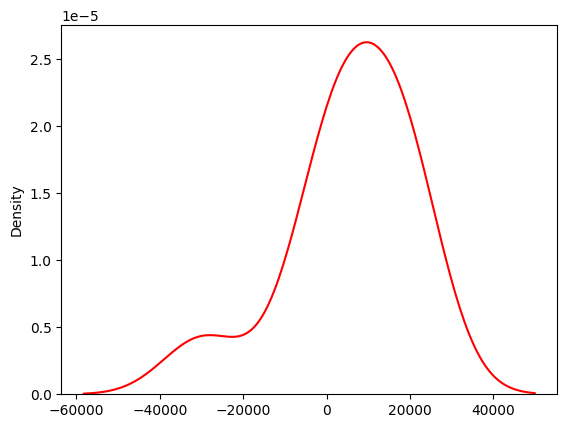

In [13]:
#checking normal residual
residual=y_test-y_pred
sns.kdeplot(residual, color='red')

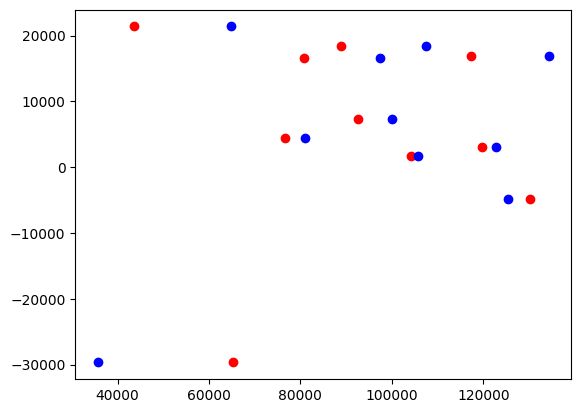

In [14]:
#checking homoscedasticity
plt.scatter(y_pred, residual, color='red')
plt.scatter(y_test, residual, color='blue')

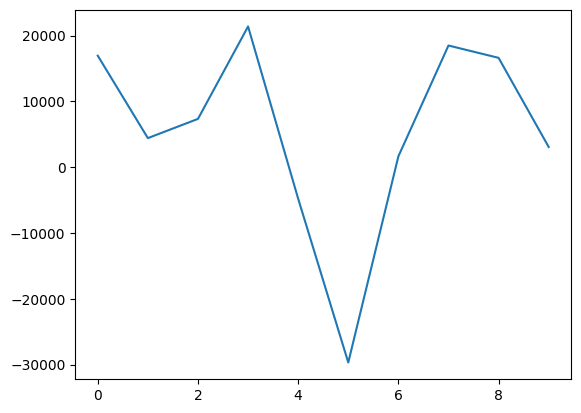

In [15]:
#checking auto-correlation
plt.plot(residual)

In [16]:
r2_score=r2_score(y_test, y_pred)
print(f"r2 score : {r2_score}")
rmse= root_mean_squared_error(y_test, y_pred)
print(f"RMSE: {rmse}")

r2 score : 0.7098513863275284
RMSE: 15328.406556000056


In [ ]:
#check p-values and confidence interval
import statsmodels.api as sm
X_train=sm.add_constant(X_train)
model=sm.OLS(y_train,X_train).fit(cov_type='HC3') #use cov_type when there is heteroscdecastiicity i.e. diff of variance of residuals

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.803
Model:                            OLS   Adj. R-squared:                  0.774
Method:                 Least Squares   F-statistic:                     54.09
Date:                Thu, 04 Jun 2026   Prob (F-statistic):           3.25e-15
Time:                        11:16:42   Log-Likelihood:                -449.59
No. Observations:                  40   AIC:                             911.2
Df Residuals:                      34   BIC:                             921.3
Df Model:                           5                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.157e+05   3490.641     33.132      0.0

c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 6, but rank is 5
  warnings.warn('covariance of constraints does not have full '


- Thus only X4 truly matters